In [3]:
import os, joblib, gc, time
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

dataset_path = "/content/drive/MyDrive/Colab Notebooks"
split_file = os.path.join(dataset_path, "dataset_split.joblib")

print("Memuat dataset...")
data = joblib.load(split_file)

feat_names = data['features']
toxic = [
    'Pkt Len Var', 'Bwd IAT Mean', 'Down/Up Ratio', 'ACK Flag Cnt',
    'Bwd Pkt Len Min', 'Active Mean', 'Fwd Pkt Len Min', 'Pkt Len Min',
    'Fwd URG Flags', 'Active Min', 'Active Std', 'Active Max',
    'Idle Std', 'SYN Flag Cnt'
]

healthy_idx = [i for i, f in enumerate(feat_names) if f not in toxic]
healthy_names = [f for f in feat_names if f not in toxic]

X_train = data['X_train'][:, healthy_idx].astype('float32')
y_train = data['y_train']
X_val = data['X_val'][:, healthy_idx].astype('float32')
y_val = data['y_val']
X_test = data['X_test'][:, healthy_idx].astype('float32')
y_test = data['y_test']

del data
gc.collect()
print(f"Data siap menggunakan {len(healthy_names)} fitur.")

Memuat dataset...
Data siap menggunakan 34 fitur.


In [4]:
from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb
import numpy as np

np.random.seed(42)
tune_idx = np.random.choice(len(X_train), int(len(X_train) * 0.05), replace=False)
X_tune, y_tune = X_train[tune_idx], y_train[tune_idx]

param_dist = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 64, 128],
    'max_depth': [10, 20, -1],
    'min_child_samples': [20, 50, 100],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

lgb_base = lgb.LGBMClassifier(
    objective='binary',
    boosting_type='gbdt',
    class_weight='balanced',
    n_jobs=-1,
    verbosity=-1,
    random_state=42
)

print(f"Memulai Hyperparameter Tuning pada {len(X_tune):,} baris data...")
random_search_lgb = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='roc_auc',
    verbose=1,
    random_state=42
)

random_search_lgb.fit(X_tune, y_tune)

print(f"\nParameter Terbaik: {random_search_lgb.best_params_}")

Memulai Hyperparameter Tuning pada 564,800 baris data...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut


Parameter Terbaik: {'subsample': 0.8, 'num_leaves': 128, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': 20, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [5]:
import time

best_params = {
    'subsample': 0.8,
    'num_leaves': 128,
    'n_estimators': 500,
    'min_child_samples': 20,
    'max_depth': 20,
    'learning_rate': 0.01,
    'colsample_bytree': 0.8,
    'objective': 'binary',
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': -1
}

print("Melatih LightGBM pada data penuh ...")
final_lgbm = lgb.LGBMClassifier(**best_params)

start_t = time.time()
final_lgbm.fit(X_train, y_train)
end_t = time.time()

print(f"Training selesai dalam {end_t - start_t:.2f} detik!")

Melatih LightGBM pada data penuh ...
Training selesai dalam 1405.88 detik!


Melakukan prediksi pada data test...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



HASIL EVALUASI LIGHTGBM
              precision    recall  f1-score   support

      Benign     0.9913    0.9932    0.9923   2008536
      Attack     0.9664    0.9577    0.9621    412040

    accuracy                         0.9871   2420576
   macro avg     0.9789    0.9755    0.9772   2420576
weighted avg     0.9871    0.9871    0.9871   2420576

-------------------------------------------------------
False Positive Rate (FPR) : 0.6829%
Recall (Detection Rate)   : 95.77%
F1-Score (Attack)         : 96.21%


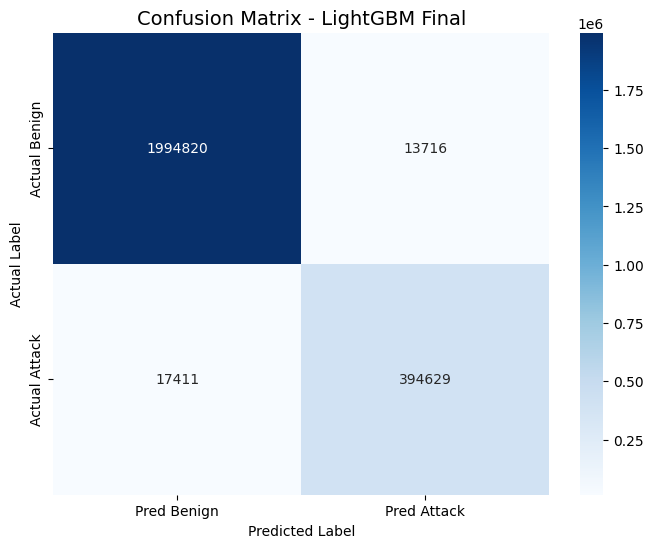

In [6]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

print("Melakukan prediksi pada data test...")
y_pred_lgbm = final_lgbm.predict(X_test)
y_prob_lgbm = final_lgbm.predict_proba(X_test)[:, 1]

cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
tn, fp, fn, tp = cm_lgbm.ravel()
fpr_lgbm = (fp / (fp + tn)) * 100
recall_lgbm = (tp / (tp + fn)) * 100
f1_attack = f1_score(y_test, y_pred_lgbm)

print("\n" + "="*55)
print("HASIL EVALUASI LIGHTGBM")
print("="*55)
print(classification_report(y_test, y_pred_lgbm, target_names=['Benign', 'Attack'], digits=4))
print("-" * 55)
print(f"False Positive Rate (FPR) : {fpr_lgbm:.4f}%")
print(f"Recall (Detection Rate)   : {recall_lgbm:.2f}%")
print(f"F1-Score (Attack)         : {f1_attack*100:.2f}%")
print("="*55)

# 3. Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Benign', 'Pred Attack'],
            yticklabels=['Actual Benign', 'Actual Attack'])
plt.title('Confusion Matrix - LightGBM Final', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [7]:
from sklearn.ensemble import IsolationForest
import numpy as np

print("Melatih Isolation Forest di Ruang Fitur sehat...")

X_benign_train = X_train[y_train == 0]
iso_forest_lgbm = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)
iso_forest_lgbm.fit(X_benign_train)
print("Isolation Forest siap!")

missed_by_lgbm = np.where((y_test == 1) & (y_pred_lgbm == 0))[0]
total_missed = len(missed_by_lgbm)

print(f"\nTotal serangan yang lolos dari LightGBM: {total_missed:,} data.")

if total_missed > 0:
    print("Mengecek kemampuan deteksi anomali pada celah tersebut...")
    saved_count = 0

    for idx in missed_by_lgbm:
        is_normal = iso_forest_lgbm.predict(X_test[idx].reshape(1, -1))[0]
        if is_normal == -1:
            saved_count += 1

    rescue_rate = (saved_count / total_missed) * 100
    print("-" * 50)
    print(f"HASIL PENYELAMATAN (RESCUE RATE)")
    print("-" * 50)
    print(f"Serangan Terselamatkan : {saved_count:,} data")
    print(f"Persentase Rescue      : {rescue_rate:.2f}%")
    print("-" * 50)
else:
    print("LightGBM tidak meloloskan serangan apapun!")

Melatih Isolation Forest di Ruang Fitur sehat...
Isolation Forest siap!

Total serangan yang lolos dari LightGBM: 17,411 data.
Mengecek kemampuan deteksi anomali pada celah tersebut...
--------------------------------------------------
HASIL PENYELAMATAN (RESCUE RATE)
--------------------------------------------------
Serangan Terselamatkan : 175 data
Persentase Rescue      : 1.01%
--------------------------------------------------
